In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, RocCurveDisplay

In [34]:
mental_health = pd.read_csv("https://raw.githubusercontent.com/silkfiy/social-media-mental-health-classifier/refs/heads/main/mental_health_social_media_dataset.csv")

## EDA

In [35]:
mental_health.head()

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


In [4]:
mental_health.describe()

,age,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,29.947800,373.058200,175.331600,0.864200,1.835400,7.134660,22.693400,2.510400,7.107600,5.625800
std,12.279936,106.003916,71.209329,0.555176,0.943443,0.533184,10.602862,0.794996,1.062378,0.759928
min,13.000000,140.000000,35.000000,0.000000,0.000000,6.400000,8.000000,1.000000,5.000000,4.000000
25%,21.000000,310.000000,118.000000,1.000000,1.000000,6.700000,14.000000,2.000000,6.000000,5.000000
50%,27.000000,388.000000,170.000000,1.000000,2.000000,7.100000,21.000000,3.000000,7.000000,6.000000
75%,35.250000,461.000000,231.000000,1.000000,2.000000,7.450000,29.000000,3.000000,8.000000,6.000000
max,69.000000,520.000000,338.000000,2.000000,4.000000,8.300000,46.000000,4.000000,9.000000,7.000000


In [5]:
print(mental_health.shape)
print(mental_health.columns)

(5000, 15)
Index(['person_name', 'age', 'date', 'gender', 'platform',
       'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level', 'mental_state'],
      dtype='str')


lets see if there are any duplicate rows in the data we will actually look at

In [6]:
mental_health = mental_health.drop(columns = ['person_name', 'date'])
mental_health = mental_health.drop_duplicates()
mental_health.shape

(4707, 13)

In [7]:
mental_health.isna().sum()

age                            0
gender                         0
platform                       0
daily_screen_time_min          0
social_media_time_min          0
negative_interactions_count    0
positive_interactions_count    0
sleep_hours                    0
physical_activity_min          0
anxiety_level                  0
stress_level                   0
mood_level                     0
mental_state                   0
dtype: int64

<Axes: xlabel='mental_state'>

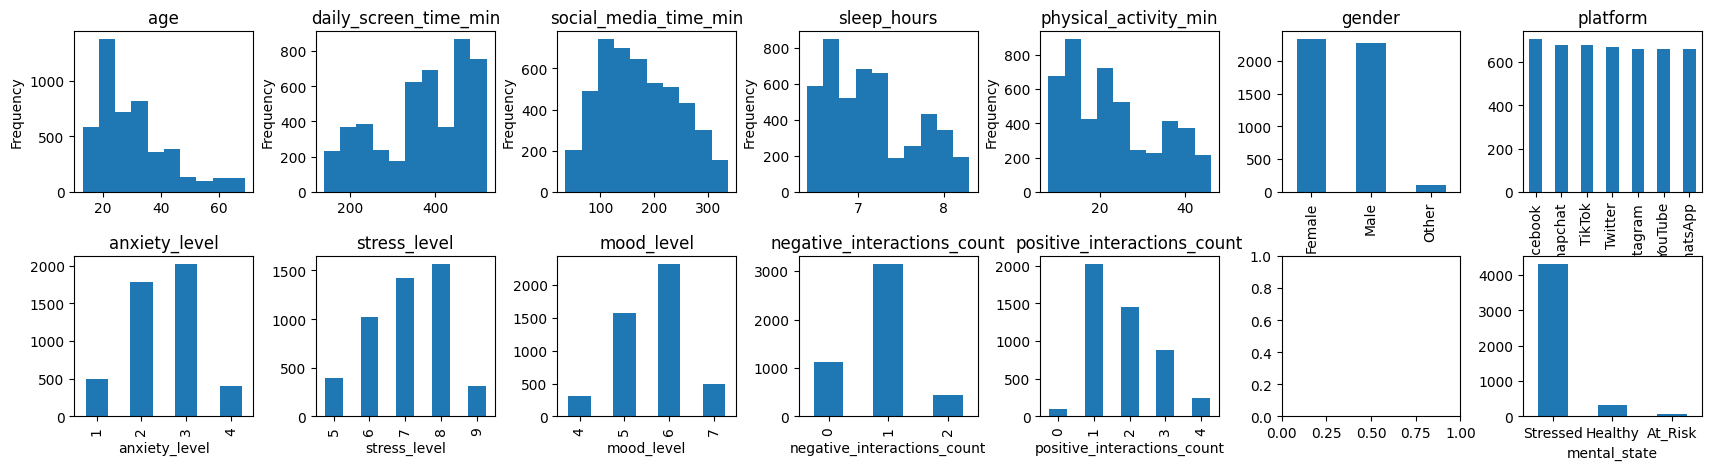

In [8]:
fig, axes = plt.subplots(figsize = (21, 5), nrows=2, ncols=7)
continuous_cols = ['age', 'daily_screen_time_min',
       'social_media_time_min', 'sleep_hours', 'physical_activity_min']
categorical_cols = ['gender', 'platform'] 
ordinal_cols = ['anxiety_level', 'stress_level', 'mood_level']
count_cols = ['negative_interactions_count', 'positive_interactions_count']
plt.subplots_adjust(hspace = 0.4, wspace = 0.35)
col = 0
for c in continuous_cols:
    mental_health[c].plot(kind='hist', ax = axes[0][col], title = c)
    col += 1
for c in categorical_cols:
    mental_health[c].value_counts().plot(kind='bar', ax = axes[0][col], title = c)
    col += 1
col = 0
for c in (ordinal_cols+count_cols):
    mental_health[c].value_counts().sort_index().plot(kind='bar', ax = axes[1][col], title = c)
    col += 1
mental_health['mental_state'].value_counts().plot(kind='bar', ax=axes[1][6], rot=0)

Feature encoding:

In [9]:
dummies = pd.get_dummies(mental_health, columns=['gender', 'platform'], drop_first=True)
dummies['mental_state'] = dummies['mental_state'].map(lambda x: 0 if x=='Stressed' else 1 if x=='Healthy' else 2)
dummies.columns

Index(['age', 'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level', 'mental_state', 'gender_Male', 'gender_Other',
       'platform_Instagram', 'platform_Snapchat', 'platform_TikTok',
       'platform_Twitter', 'platform_WhatsApp', 'platform_YouTube'],
      dtype='str')

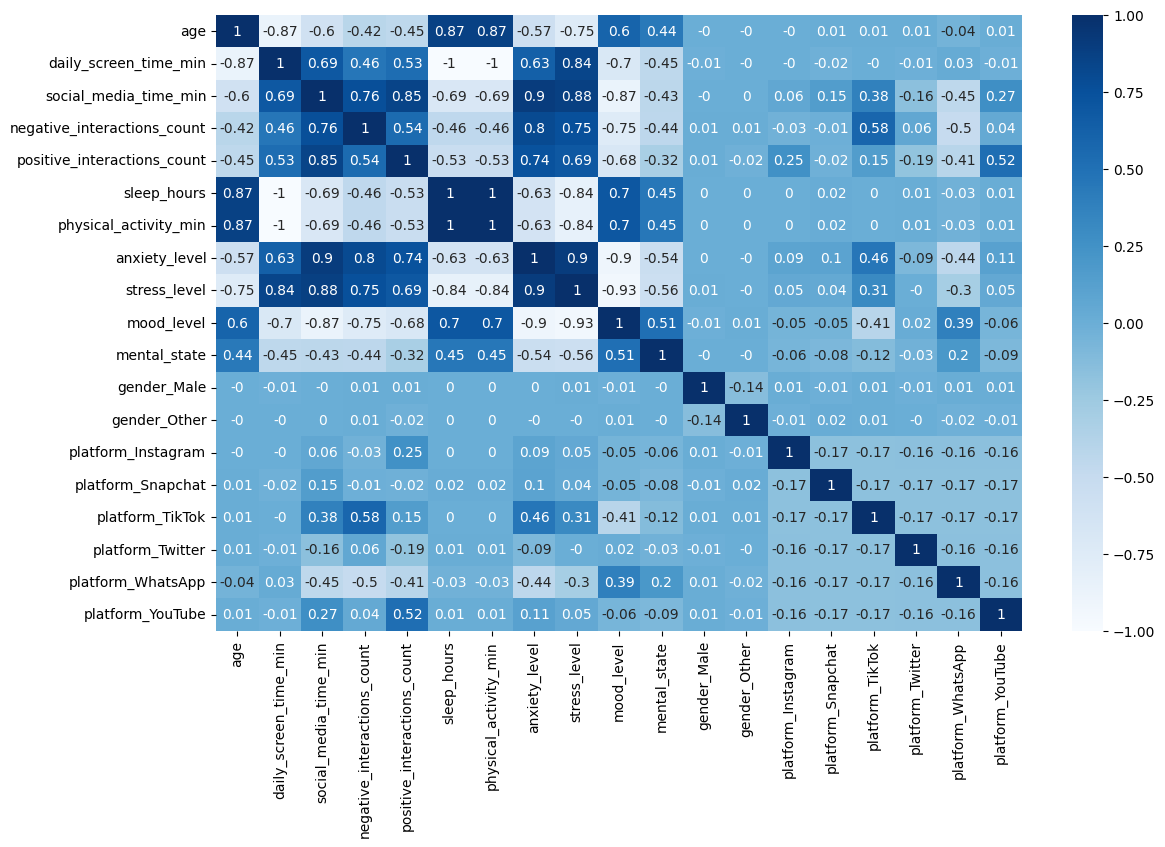

In [10]:
corr_matrix = dummies.corr().round(2)
plt.figure(figsize=(13,8))
sns.heatmap(corr_matrix, annot=True, cmap="Blues");

seems like gender doesn't have much of an effect

In [11]:
X = dummies.drop('mental_state', axis = 1)
y = dummies['mental_state']

## Modeling

In [12]:
seed = 42
np.random.seed(42)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = 0.2, random_state = seed)

In [13]:
# lets try LinearSVC, K-neighbors, logistic, and randomforest
models = {
    'LinearSVC' : sklearn.svm.LinearSVC(random_state=seed),
    'KNeighbors' : sklearn.neighbors.KNeighborsClassifier(),
    'LogisticRegression' : sklearn.linear_model.LogisticRegression(random_state=seed, max_iter=800),
    'RandomForest' : sklearn.ensemble.RandomForestClassifier(random_state=seed)
}

def fit_score(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_preds = model.predict(X_test)
    return sklearn.metrics.f1_score(y_test, y_preds, average='macro')

In [14]:
model_scores = []
for name, model in models.items():
    model_scores.append((name, fit_score(model, X_train, X_test, y_train, y_test)))
model_scores

[('LinearSVC', 0.9749276759884281),
 ('KNeighbors', 0.9669651624052472),
 ('LogisticRegression', 0.9749276759884281),
 ('RandomForest', 1.0)]

`RandomForestClassifier` is the best model, but accuracy is not my highest priority \
I will choose `LinearSVC` to have visible results when hyperparameter tuning.

## more data manipulation
since i'm using `LinearSVC`, I'll scale the data

In [15]:
dummies.columns

Index(['age', 'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level', 'mental_state', 'gender_Male', 'gender_Other',
       'platform_Instagram', 'platform_Snapchat', 'platform_TikTok',
       'platform_Twitter', 'platform_WhatsApp', 'platform_YouTube'],
      dtype='str')

In [16]:
binary_cols = ['gender_Male', 'gender_Other',
       'platform_Instagram', 'platform_Snapchat', 'platform_TikTok',
       'platform_Twitter', 'platform_WhatsApp', 'platform_YouTube']
other_cols = ['age', 'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level']

In [17]:
scaler = StandardScaler()
transformer = ColumnTransformer([('scaler', scaler, other_cols)], remainder = 'passthrough')
X_train_scaled = transformer.fit_transform(X_train)
X_test_scaled = transformer.transform(X_test)

#### retest model for new baseline

In [18]:
model = LinearSVC(random_state=seed)
model.fit(X_train_scaled, y_train)
y_preds = model.predict(X_test_scaled)
print(sklearn.metrics.classification_report(y_test, y_preds))
print(f'f1 macro: {sklearn.metrics.f1_score(y_test, y_preds, average='macro')}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       864
           1       0.94      0.98      0.96        60
           2       0.93      0.78      0.85        18

    accuracy                           0.99       942
   macro avg       0.96      0.92      0.94       942
weighted avg       0.99      0.99      0.99       942

f1 macro: 0.9359448139935945


This seems to be worse than the unscaled data

## Hyperparameter tuning

In [19]:
pipeline = Pipeline([('transformer', transformer),('model', LinearSVC(random_state=seed))])

In [20]:
cv = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True)
print(f'5-fold cross-val score for scaled dat: {np.mean(cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro'))}')

5-fold cross-val score for scaled dat: 0.9039598738518929


In [21]:
rows_list = []
for i in range(20):
    rows_list.append({'scaled': np.mean(cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')), 'unscaled': np.mean(cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro'))})
df = pd.DataFrame(rows_list)

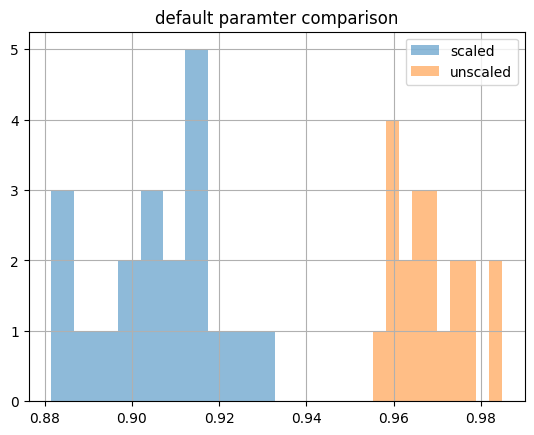

In [22]:
df['scaled'].hist(alpha=0.5, label = 'scaled')
df['unscaled'].hist(alpha=0.5,label = 'unscaled')
plt.legend()
plt.title('default paramter comparison')
plt.show()

certainly, the scaled data is doing worse!\
let us remedy this by hypertuning

In [23]:
pipeline.named_steps['model']

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [24]:
range_C = [0.01, 0.05, 0.25, 0.75, 1, 5, 25, 50, 100, 150, 250, 500]
grid = {
    'model__C': range_C
}

In [25]:
cv_seeded = sklearn.model_selection.RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state = seed)
grid_search = GridSearchCV(pipeline, param_grid=grid, scoring='f1_macro', cv=cv_seeded)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__C': 150}
0.9901277926092347


now i want to compare it to the unscaled data to, so lets find a good C for that

In [26]:
gs_unscaled = GridSearchCV(estimator=model, param_grid={'C': range_C}, scoring='f1_macro', cv=cv_seeded)
gs_unscaled.fit(X_train, y_train)
print(gs_unscaled.best_params_)
print(gs_unscaled.best_score_)

{'C': 250}
0.9849963268474607


since we have our optimal parameters, lets evaluate our models using `cross_val_score`

In [27]:
pipeline.set_params(**grid_search.best_params_)
model.set_params(**gs_unscaled.best_params_)
rows_list = []
for i in range(50):
    rows_list.append({'scaled': np.mean(cross_val_score(pipeline, X, y, cv=cv, scoring='f1_macro')), 'unscaled': np.mean(cross_val_score(model, X, y, cv=cv, scoring='f1_macro'))})
df = pd.DataFrame(rows_list)

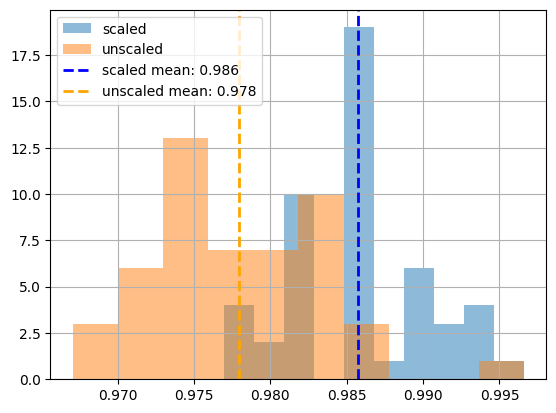

In [28]:
df['scaled'].hist(alpha=0.5, label = 'scaled')
df['unscaled'].hist(alpha=0.5,label = 'unscaled')
plt.axvline(df['scaled'].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'scaled mean: {df["scaled"].mean():.3f}')
plt.axvline(df['unscaled'].mean(), color='orange', linestyle='dashed', linewidth=2, label=f'unscaled mean: {df["unscaled"].mean():.3f}')
plt.legend()
plt.show()

In [29]:
t_stat, p_value = stats.ttest_rel(df['scaled'], df['unscaled'])
print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.3f}')

t-statistic: 7.556
p-value: 0.000


## evaluation metrics and feature importance

In [30]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [31]:
y_preds = pipeline.predict(X_test)
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       864
           1       0.97      1.00      0.98        60
           2       1.00      0.89      0.94        18

    accuracy                           1.00       942
   macro avg       0.99      0.96      0.97       942
weighted avg       1.00      1.00      1.00       942



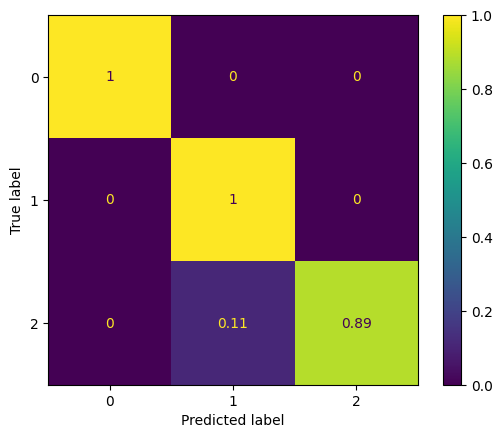

In [32]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_preds, normalize='true')

<Axes: ylabel='feature'>

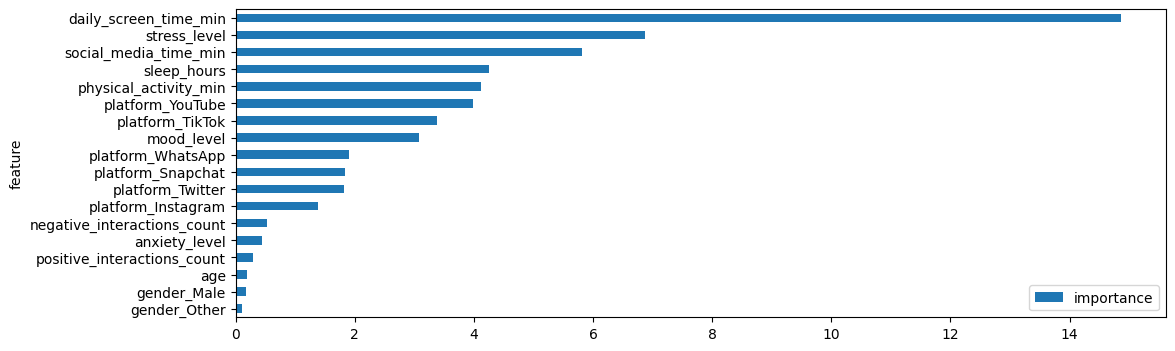

In [33]:
coefficients = pipeline.named_steps['model'].coef_
importance = np.mean(np.abs(coefficients), axis=0)
feature_importance = pd.DataFrame({'feature': X.columns,'importance': importance}).sort_values('importance', ascending=True)
feature_importance.plot(x='feature', y='importance', kind='barh', figsize=(12, 4))